In [1]:
import sys
import os
from pathlib import Path
from copy import deepcopy
project_dir = Path(os.path.abspath('')).parent
sys.path.insert(0, project_dir.as_posix())

from tqdm import trange, tqdm
import numpy as np
import torch
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
from sentence_transformers import SentenceTransformer

%load_ext autoreload
%autoreload 2
import train_dpr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
top_k = [5, 20, 40, 60, 80, 100]
acc_df = pd.DataFrame(columns=["model"] + [f"top-{k}" for k in top_k])


def append_result(model_name, accuracy):
    acc_df.loc[len(acc_df)] = [model_name] + [accuracy[k] for k in top_k]

In [3]:
# ----- BM25 and SBERT -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="none",
    train_bert=True,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=256)

acc_bm25 = train_dpr.benchmark_retriever("bm25", test_ds, top_k=top_k, batch_size=256)
append_result("BM25", acc_bm25)
append_result("SBERT", acc)

# ----- BERT-Mini -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="none",
    train_bert=True,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=256)
append_result("BERT-Mini", acc)

# ----- BERT-Mini-DPR -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="dpr_bert7",
    train_bert=True,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=256)
append_result("BERT-Mini-DPR", acc)

# ----- MiniMind2-Small-Pretrain -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="pretrain",
    train_bert=False,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=128)
append_result("MiniMind2-Small-Pretrain", acc)

# ----- MiniMind-Small-DPR -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="dpr",
    train_bert=False,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=128)
append_result("MiniMind2-Small-DPR", acc)

所加载Model可训练参数：11.171 百万


Split strings:   0%|          | 0/2112 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/2112 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/2112 [00:00<?, ?it/s]

Split strings:   0%|          | 0/2112 [00:00<?, ?it/s]

...

100%|██████████| 9/9 [00:02<00:00,  3.45it/s]


所加载Model可训练参数：25.830 百万


100%|██████████| 17/17 [00:22<00:00,  1.33s/it]


所加载Model可训练参数：25.830 百万


100%|██████████| 17/17 [00:23<00:00,  1.41s/it]


In [4]:
acc_df_show = deepcopy(acc_df)
for i in range(len(acc_df_show)):
    for k in top_k:
        acc_df_show.at[i, f"top-{k}"] = f"{acc_df_show.at[i, f'top-{k}']:.3f}"
acc_df_show

,model,top-5,top-20,top-40,top-60,top-80,top-100
0,BM25,0.916,0.955,0.965,0.971,0.974,0.977
1,SBERT,0.884,0.933,0.951,0.965,0.977,0.980
2,BERT-Mini,0.312,0.453,0.531,0.591,0.621,0.650
3,BERT-Mini-DPR,0.806,0.886,0.917,0.928,0.938,0.947
4,MiniMind2-Small-Pretrain,0.010,0.028,0.043,0.057,0.075,0.089
5,MiniMind2-Small-DPR,0.064,0.130,0.192,0.231,0.268,0.296


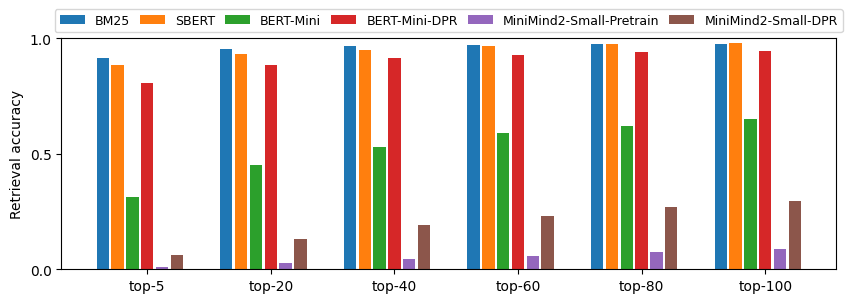

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
mpl.rcParams["font.size"] = 10
for i in range(len(acc_df)):
    model, *values = acc_df.loc[i].tolist()
    xs = np.arange(len(values))
    xs = xs + (i - len(values) // 2) * 0.12
    ax.bar(xs, values, label=model, width=0.1)
ax.set_ylim(0, 1)
ax.set_ylabel("Retrieval accuracy")
ax.set_yticks([0, 0.5, 1])
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels([f"top-{k}" for k in top_k])
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    fontsize=9,
    ncol=len(acc_df),
    columnspacing=0.8,
)